In [ ]:
import math
from functools import cache
from typing import Final, Tuple
							
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt

FloatArray: Final = npt.NDArray[np.float64]

In [2]:
@cache
def _ln_stirling_recursive(n: int, k: int) -> float:
    """Private helper using memoized recursion to get ln S(n,k)."""
    if k == 0 and n == 0:
        return 0.0  # ln(1)
    if k == 0 or k > n:
        return -math.inf
    if k == n:
        return 0.0  # ln(1)

    # ln( k * S(n-1, k) + S(n-1, k-1) )
    ln_a: float = _ln_stirling_recursive(n - 1, k - 1)
    ln_b: float = _ln_stirling_recursive(n - 1, k)
    if ln_b != -math.inf:
        ln_b += math.log(k)

    if ln_a == -math.inf:
        return ln_b
    if ln_b == -math.inf:
        return ln_a

    m: float = max(ln_a, ln_b)
    return m + math.log1p(math.exp(-abs(ln_a - ln_b)))


def stirling_log10_table(max_c: int) -> FloatArray:
    """Compute a table of log10 Stirling numbers of the second kind.

    # Parameters:
     - `max_c : int`
        Maximum value of `c` (inclusive) to compute. Requires `max_c >= 1`.

    # Returns:
     - `FloatArray`
        A `(max_c + 1, max_c + 1)` array `T` where `T[c, k] = log10(S(c, k))`
        and `-inf` for invalid entries.

    # Usage:
    ```python
    log_tbl = stirling_log10_table(10)
    print(log_tbl[10, 3])  # log10 S(10,3)
    ```
    """
    log10_tbl: FloatArray = np.full((max_c + 1, max_c + 1), -math.inf, dtype=np.float64)

    ln10: Final[float] = math.log(10.0)

    for c in range(max_c + 1):
        # exploit symmetry: k == 0 handled by default -inf
        for k in range(1, c + 1):
            log10_tbl[c, k] = _ln_stirling_recursive(c, k) / ln10

    return log10_tbl


def plot_stirling_heatmap(
    max_c: int = 1000,
    sample_step: int = 1,
    *,
    cmap: str = "viridis",
    figsize: Tuple[int, int] = (10, 10),
    show: bool = True,
    save_path: str | None = None,
) -> FloatArray:
    """Plot a log10 heatmap of Stirling numbers of the second kind, with maxima markers.

    Red ``"x"`` markers highlight the `k` that maximizes ``S(c, k)`` (for ``1 ≤ k < c``)
    for every sampled ``c`` column.

    # Parameters:
     - `max_c : int`
        Largest ``c`` to include (`≥ 1`).
     - `sample_step : int`
        Sub-sampling stride (`≥ 1`).  A stride of ``n`` keeps every ``n``-th
        row/column to accelerate plotting.
     - `cmap : str`
        Matplotlib colormap (default ``"viridis"``).
     - `figsize : Tuple[int, int] | None`
        Figure size in inches (default determined automatically).
     - `show : bool`
        Display interactively if ``True``; otherwise close the figure.
     - `save_path : str | None`
        If not ``None``, save the figure to this path (e.g. ``"heatmap.png"``).

    # Returns:
     - `None`

    # Usage:
    ```python
    plot_stirling_heatmap(400, sample_step=2)
    ```
    """
    if max_c < 1:
        raise ValueError("`max_c` must be ≥ 1.")
    if sample_step < 1:
        raise ValueError("`sample_step` must be ≥ 1.")

    # Reuse the previously‑defined table generator
    log10_tbl: FloatArray = stirling_log10_table(max_c)

    # Build dense triangular array (k rows, c columns) with NaN for invalid cells
    heatmap: FloatArray = np.full((max_c, max_c), np.nan, dtype=np.float64)
    for c in range(1, max_c + 1):
        heatmap[: c - 1, c - 1] = log10_tbl[c, 1:c]

    # Determine k that maximizes S(c, k) for each c (excluding k == c)
    best_k: list[int] = [0] * (max_c + 1)
    for c in range(2, max_c + 1):
        k_vals: FloatArray = log10_tbl[c, 1:c]  # length c-1
        best_k[c] = int(1 + int(np.argmax(k_vals)))

    # Apply sub‑sampling to heatmap
    heatmap = heatmap[::sample_step, ::sample_step]

    # Compute marker positions in sampled coordinate space
    xs: list[int] = []
    ys: list[int] = []
    for c in range(2, max_c + 1):
        if (c - 1) % sample_step != 0:
            continue  # this column is not plotted
        k_opt: int = best_k[c]
        if (k_opt - 1) % sample_step != 0:
            continue  # row skipped by sampling
        xs.append((c - 1) // sample_step)
        ys.append((k_opt - 1) // sample_step)

    # Plot
    fig, ax = plt.subplots(figsize=figsize or (10, 8))
    im = ax.imshow(heatmap, origin="lower", aspect="auto", cmap=cmap)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10} S(c, k)$")

    # Overlay maxima
    ax.scatter(xs, ys, marker="x", color="red", s=20, linewidths=0.75, zorder=3)

    step_lbl: int = sample_step
    ax.set_xlabel("$c$")
    ax.set_ylabel("$k$")
    ax.set_title("# of possible groupings given $c$ components and $k$ groups\na.k.a. Stirling numbers of the second kind $S(c, k)$")

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300)
    if show:
        plt.show()
    else:
        plt.close(fig)
        
    return heatmap



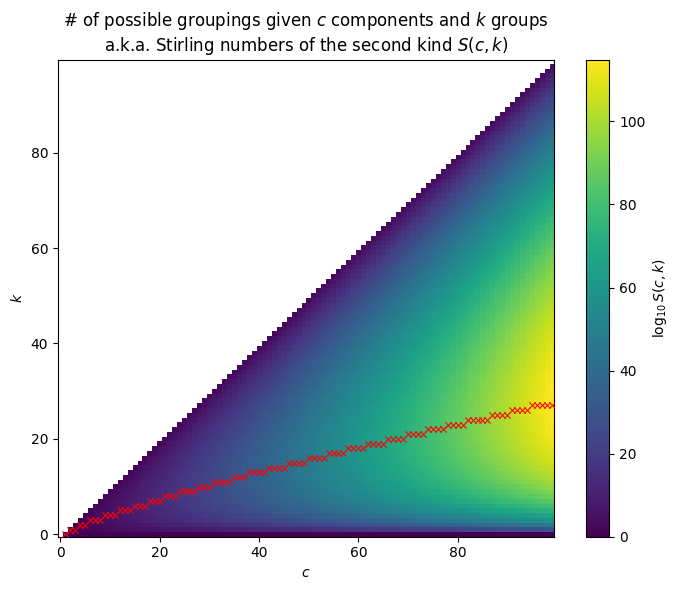

In [3]:
plot_stirling_heatmap(max_c=100, sample_step=1,figsize=(7,6));